In [1]:
import pandas as pd
import numpy as np
test_df = pd.DataFrame({'A': [1, 2, 2, 3]})
test_df['A'].value_counts().sum()

4

In [2]:
import sys 
sys.version

'3.11.9 (v3.11.9:de54cf5be3, Apr  2 2024, 07:12:50) [Clang 13.0.0 (clang-1300.0.29.30)]'

In [3]:
# Importing important libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
# importing the file:

df = pd.read_csv('ratings_Electronics (1).csv')
df['timestamp'] = pd.to_datetime(df['1365811200'], unit='s')
df.shape

(7824481, 5)

# giving some meaning to the features

In [5]:
df = df.rename(columns={'AKM1MP6P0OYPR':'User ID','0132793040':'Product ID','5.0':'Ratings'})
df = df.drop(columns={'1365811200'})
df

,User ID,Product ID,Ratings,timestamp
0,A2CX7LUOHB2NDG,0321732944,5.0,2012-07-01
1,A2NWSAGRHCP8N5,0439886341,1.0,2013-04-29
2,A2WNBOD3WNDNKT,0439886341,3.0,2013-07-22
3,A1GI0U4ZRJA8WN,0439886341,1.0,2012-04-18
4,A1QGNMC6O1VW39,0511189877,5.0,2014-04-14
...,...,...,...,...
7824476,A2YZI3C9MOHC0L,BT008UKTMW,5.0,2014-04-04
7824477,A322MDK0M89RHN,BT008UKTMW,5.0,2011-08-15
7824478,A1MH90R0ADMIK0,BT008UKTMW,4.0,2014-07-01
7824479,A10M2KEFPEQDHN,BT008UKTMW,4.0,2011-02-13


In [6]:
df['timestamp'].min(),df['timestamp'].max() # timeframe  lies between 1998-12-04 to 2014-07-23

(Timestamp('1998-12-04 00:00:00'), Timestamp('2014-07-23 00:00:00'))

In [7]:
df.isna().sum() # looking for missing values

User ID       0
Product ID    0
Ratings       0
timestamp     0
dtype: int64

In [8]:
df_once = df.groupby('Product ID').filter(lambda x: len(x) == 1)

df_once['Product ID'].nunique() # there exist 179737 products which are sold for once

179737

In [9]:
df.shape

(7824481, 4)

In [10]:
df['Product ID'].count(),len(df['Product ID']),df['Product ID'].nunique()

(7824481, 7824481, 476001)

In [11]:
df['Product ID'].value_counts(sort=True)

B0074BW614    18244
B00DR0PDNE    16454
B007WTAJTO    14172
B0019EHU8G    12285
B006GWO5WK    12226
              ...  
B004WL91KI        1
B004WL9FK4        1
B004WL9Q2Q        1
B004WL9R8O        1
BT008V9J9U        1
Name: Product ID, Length: 476001, dtype: int64

In [12]:
# pip install "numpy<2.0" pandas scikit-surprise matplotlib

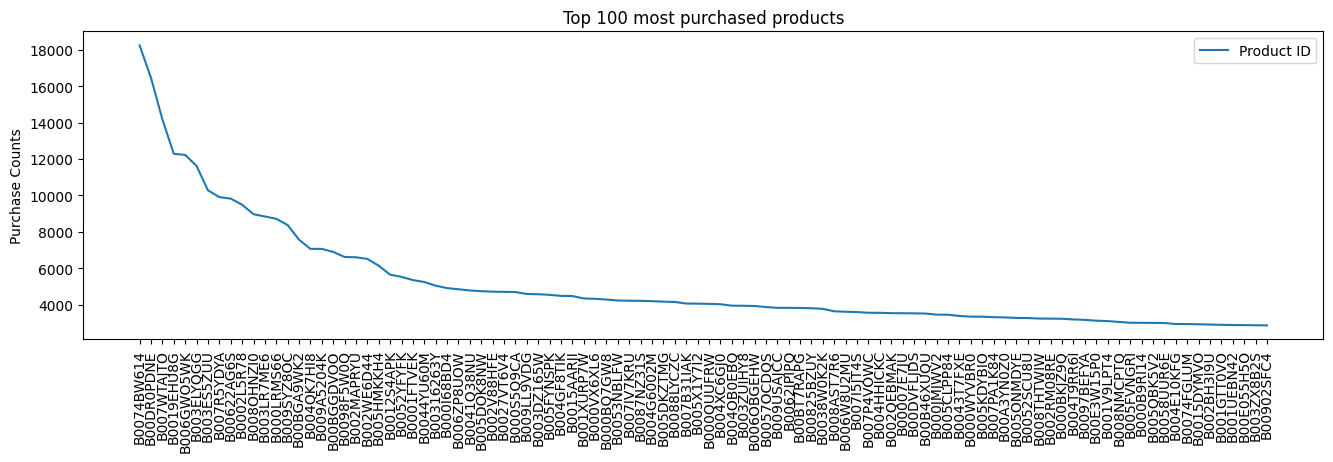

In [13]:
# top 100 most purchased products are:

products = [df['Product ID'].value_counts(sort=True).iloc[:100]]

plt.figure(figsize=(16,4))
plt.title('Top 100 most purchased products')
sns.lineplot(products)
plt.ylabel('Purchase Counts')
plt.xticks(rotation=90)
plt.show()

# EDA: 1. Analysing Popularity vs Trends 

In [14]:
# In this section, we are trying to find the average ratings per product.

avg_ratings_series = df.groupby('Product ID')['Ratings'].mean()
avg_rating_list = avg_ratings_series.tolist()
len(avg_rating_list)

476001

In [15]:
# Here we count the purchases which are done 
purchase_count = df['Product ID'].value_counts(sort=False)
purchase_count

0321732944     1
0439886341     3
0511189877     6
0528881469    27
0558835155     1
              ..
BT008G3W52     1
BT008SXQ4C     1
BT008T2BGK     1
BT008UKTMW    15
BT008V9J9U     1
Name: Product ID, Length: 476001, dtype: int64

In [16]:
data = {
    'Product ID': df['Product ID'].unique(),
    'Purchase_count': purchase_count,
    'Average_rating': avg_rating_list
}

df_prod_avg = pd.DataFrame(data)


df_prod_avg

,Product ID,Purchase_count,Average_rating
0321732944,0321732944,1,5.000000
0439886341,0439886341,3,1.666667
0511189877,0511189877,6,4.500000
0528881469,0528881469,27,2.851852
0558835155,0558835155,1,3.000000
...,...,...,...
BT008G3W52,BT008G3W52,1,5.000000
BT008SXQ4C,BT008SXQ4C,1,1.000000
BT008T2BGK,BT008T2BGK,1,5.000000
BT008UKTMW,BT008UKTMW,15,4.000000


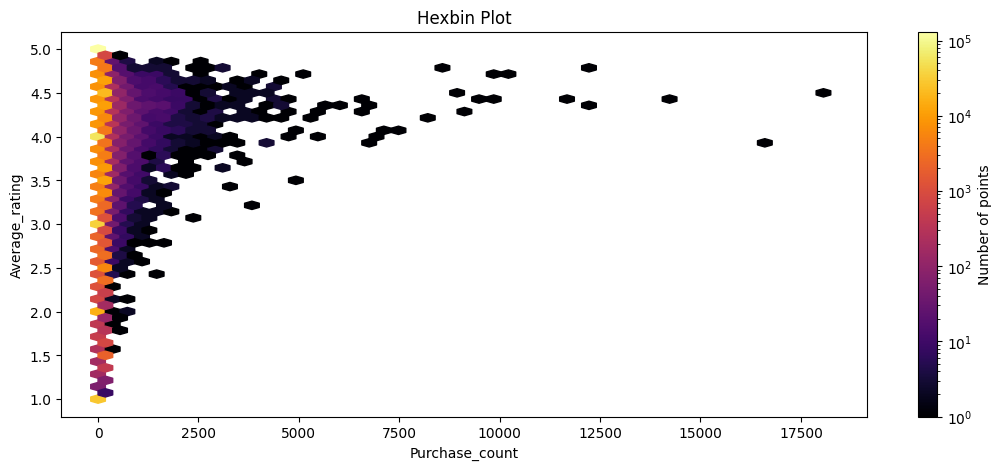

In [17]:
plt.figure(figsize=(13,5))
plt.hexbin(df_prod_avg['Purchase_count'],df_prod_avg['Average_rating'],gridsize = 50, cmap='inferno',bins = 'log')
plt.colorbar(label='Number of points')
plt.xlabel('Purchase_count')
plt.ylabel('Average_rating')
plt.title('Hexbin Plot')
plt.show()

 # EDA: 2. Temporal Analysis (trend) of top 5 most sold products per day

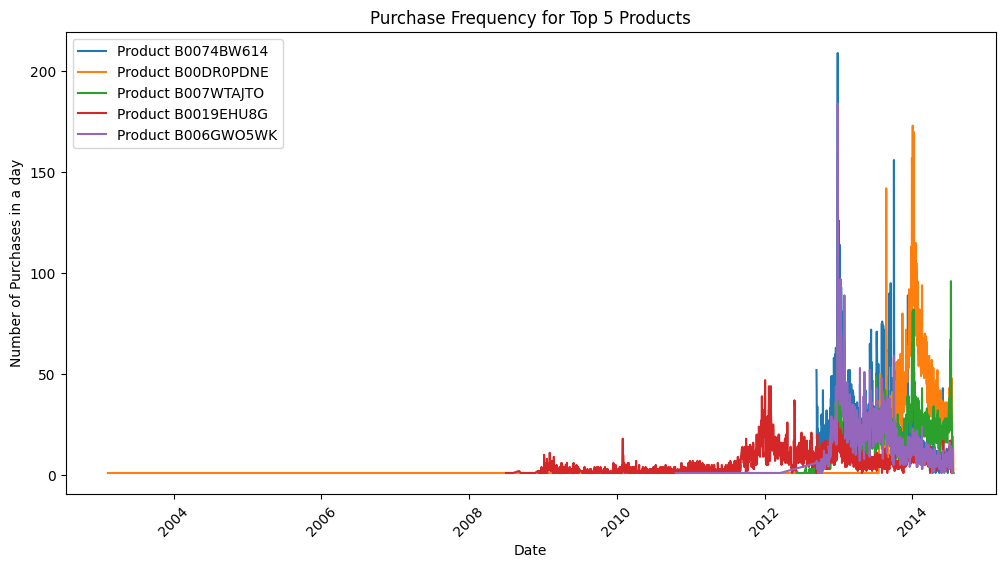

In [18]:
''' 
    top 5 most sold product from the starting time to the ending one
'''

df.sort_values(by='timestamp', ascending=True,ignore_index = True,inplace=True) # sorting the data based on time
top_5_product = df['Product ID'].value_counts().iloc[:5].index


plt.figure(figsize = (12,6))
for prod in top_5_product:
    subset = df[df['Product ID'] == prod]
    counts = subset.groupby(subset['timestamp'].dt.date).size()
    # print(counts)
    plt.plot(counts.index, counts.values,label=f'Product {prod}')

plt.title("Purchase Frequency for Top 5 Products")
plt.xlabel("Date")
plt.ylabel("Number of Purchases in a day")
plt.legend()
plt.xticks(rotation=45)
plt.show()

# Problems:
    -> if low-volume data have rating better than high-volume data then our model will prioritize more on to the lower side.
    -> if a  product was sold on 1998 and it made another sell on 2012 then we should prioritize more to the recent purchases for better outcome.
    -> collabarative filtering fails when we have a 180k once sold products, so we have to do content based filtering.

# Implementing bayesian average method to solve the problem of low-high volume density of ratings

In [19]:
# We are selecting the rich data with 50 or more active users and products been sold for 50 times.
user_counts = df['User ID'].value_counts()
active_users = user_counts[user_counts>=50].index
df_filtered = df[df['User ID'].isin(active_users)].reset_index()
df_filtered = df_filtered.drop(columns = {'index'})
df_filtered

,User ID,Product ID,Ratings,timestamp
0,A335QXPTV1RIV1,B00000J4FS,5.0,1999-10-11
1,A11P105WVK5240,B00000J58E,4.0,1999-10-19
2,ARXU3FESTWMJJ,B00000JBAT,2.0,1999-12-01
3,AQ55H30MZSV0Q,B00000J3H5,5.0,1999-12-04
4,A4GGT6O0GQNV2,B00000JSES,5.0,1999-12-21
...,...,...,...,...
125866,A3LGT6UZL99IW1,B00KXMN08E,5.0,2014-07-23
125867,A2HRHF83I3NDGT,B00H7PBWK8,5.0,2014-07-23
125868,A3CW0ZLUO5X2B1,B00JOS04PK,5.0,2014-07-23
125869,A3SU7JSTPH9CC9,B00GWR38PO,5.0,2014-07-23


In [20]:
product_counts = df_filtered['Product ID'].value_counts()
trending_products = product_counts[product_counts >= 50].index
df_final = df_filtered[df_filtered['Product ID'].isin(trending_products)].reset_index()
df_final = df_final.drop(columns = 'index')
df_final

,User ID,Product ID,Ratings,timestamp
0,A1MJMYLRTZ76ZX,B00004ZCJE,5.0,2003-06-21
1,AWH2AY17ZU7W2,B00007E7JU,5.0,2005-12-05
2,AWH2AY17ZU7W2,B00004ZCJE,3.0,2005-12-05
3,A4WEZJOIZIV4U,B00007E7JU,5.0,2005-12-07
4,A9Y5O2R4D6EH5,B00004ZCJE,3.0,2006-01-16
...,...,...,...,...
6229,A1PV5T5S4D5NPI,B007WTAJTO,5.0,2014-07-14
6230,A10PEXB6XAQ5XF,B00JP12170,4.0,2014-07-15
6231,AR1T36GLLAFFX,B004Q3R9AQ,5.0,2014-07-16
6232,AVBLGXSWRN666,B00JP12170,4.0,2014-07-17


In [56]:
# we will apply baysian average rating which will normalize/standardize those rating
# because some of the rating are of more than 1k and least is 50 only
# by doing the bayesian average we can balance the low and high rating


C = df_final['Ratings'].mean() # c is the mean rating across the df_final dataset

m = df_final.groupby('Product ID')['Ratings'].count().quantile(0.25) # m is the minimum rating required to be considered (atleast 25 percentile)

product_stats = df_final.groupby('Product ID').agg(
    Average_rating  = ('Ratings', 'mean'),
    Purchase_count = ('Ratings', 'count')
)

def bayesian_avg(x, m=m ,c=C):
    v = x['Purchase_count'] # no. of rating for the product
    R = x['Average_rating'] # average rating for the product

    return ((v/(v+m))*R) + ((m/(v+m))*C)


product_stats['Weighted_Rating'] = product_stats.apply(bayesian_avg, axis=1)

top_products = product_stats.sort_values('Weighted_Rating', ascending=False).head(10)
# top_products

# product_stats['Product ID'] = product_stats.index

product_stats

,Average_rating,Purchase_count,Weighted_Rating
Product ID,,,
B00004ZCJE,4.250000,72,4.329548
B00007E7JU,4.416667,60,4.422383
B0002L5R78,4.611940,67,4.526730
B000BQ7GW8,4.777778,54,4.596796
B000HPV3RW,4.803922,51,4.604048
...,...,...,...
B00BOHNYU6,4.714286,63,4.577200
B00DR0PDNE,3.785714,84,4.048177
B00G4UQ6U8,4.763636,55,4.591515


# Solving the problem of temporal trends where old purchases doesnt provide the insights

In [57]:
latest_date = df_final['timestamp'].max()
df_final['days_old'] = (latest_date - df_final['timestamp']).dt.days

alpha = 0.01

df_final['time_weight'] = np.exp(-alpha * df_final['days_old'])

df_final['decayed_rating'] = df_final['Ratings'] * df_final['time_weight']


df_final

,User ID,Product ID,Ratings,timestamp,days_old,time_weight,decayed_rating
0,A1MJMYLRTZ76ZX,B00004ZCJE,5.0,2003-06-21,4046,2.681917e-18,1.340958e-17
1,AWH2AY17ZU7W2,B00007E7JU,5.0,2005-12-05,3148,2.130148e-14,1.065074e-13
2,AWH2AY17ZU7W2,B00004ZCJE,3.0,2005-12-05,3148,2.130148e-14,6.390443e-14
3,A4WEZJOIZIV4U,B00007E7JU,5.0,2005-12-07,3146,2.173179e-14,1.086590e-13
4,A9Y5O2R4D6EH5,B00004ZCJE,3.0,2006-01-16,3106,3.242003e-14,9.726009e-14
...,...,...,...,...,...,...,...
6229,A1PV5T5S4D5NPI,B007WTAJTO,5.0,2014-07-14,5,9.512294e-01,4.756147e+00
6230,A10PEXB6XAQ5XF,B00JP12170,4.0,2014-07-15,4,9.607894e-01,3.843158e+00
6231,AR1T36GLLAFFX,B004Q3R9AQ,5.0,2014-07-16,3,9.704455e-01,4.852228e+00
6232,AVBLGXSWRN666,B00JP12170,4.0,2014-07-17,2,9.801987e-01,3.920795e+00


In [58]:
from surprise import Reader,SVD,Dataset
from surprise.model_selection import train_test_split
from surprise import accuracy

In [59]:
reader = Reader(rating_scale = (1,5))
data = Dataset.load_from_df(df_final[['User ID','Product ID','decayed_rating']],reader)

trainset,testset = train_test_split(data,test_size=0.2,random_state=42)


In [60]:
model = SVD(n_factors=50,random_state=42,n_epochs=20)
model.fit(trainset)

In [61]:
import pickle

with open('SVD.pkl','wb') as file:
    pickle.dump(model,file)

In [62]:
predictions = model.test(testset)
accuracy.rmse(predictions)

RMSE: 0.9948


0.9947862484024339

In [63]:
####################### gotta write something here

In [65]:
product_stats.to_csv('product_stats.csv')

In [ ]:
def recommendation_engine(user_id,num_recs = 5):
    product_ids = product_stats.index.tolist()

    predictions = []

    for pid in product_ids:
        pred = model.predict(user_id,pid)
        predictions.append((pid,pred.est))

    rec_df = pd.DataFrame(predictions, columns=['Product ID', 'SVD_Prediction'])
    rec_df = rec_df.merge(product_stats[['Weighted_Rating']], on='Product ID')

    rec_df['Final_Score'] = ((rec_df['SVD_Prediction'] * 0.5) + (rec_df['Weighted_Rating'] * 0.5))
    
    return rec_df.sort_values('Final_Score', ascending=False).head(num_recs)

for i in range(10):
    current_user = df_final['User ID'].iloc[i]
    print(f"Top 5 Recommendations for {current_user}:")
    print(recommendation_engine(current_user))